# VINDATATHON 2026 - GRIDBREAKER

## Part 03: Revenue Time-series Forecasting Model

This section contains **feature engineering** and **data modeling** to forecast revenue for the period from January 1, 2023 to July 1, 2024.


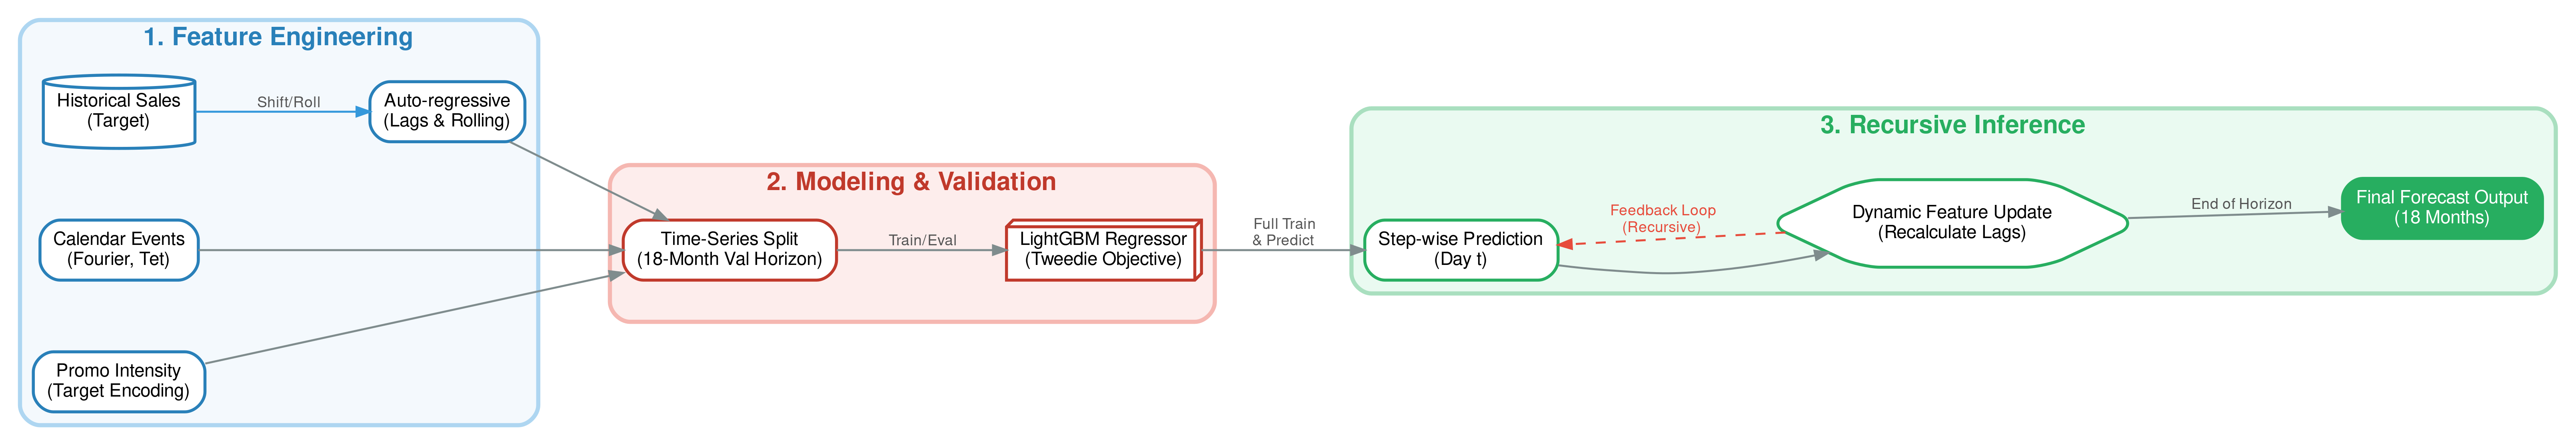

In [80]:
from graphviz import Digraph
from IPython.display import Image, display

dot = Digraph(comment='Sales Forecasting Pipeline', format='png')
dot.attr(rankdir='LR', dpi='300', nodesep='0.6', ranksep='0.8', splines='spline')
dot.attr('node', shape='rect', style='filled,rounded', fillcolor='white', 
         fontname='Segoe UI, Helvetica, Arial', fontsize='11', penwidth='1.8')
dot.attr('edge', color='#7F8C8D', penwidth='1.2', arrowsize='0.8', 
         fontname='Segoe UI, Helvetica, Arial', fontsize='9', fontcolor='#555555')

# Block Feature Engineering
with dot.subgraph(name='cluster_0') as c:
    # Dùng HTML-label (<<B>...</B>>) và tăng fontsize để in đậm cực mạnh
    c.attr(label='<<B>1. Feature Engineering</B>>', fontname='Segoe UI, Helvetica, Arial', 
           fontsize='15', fontcolor='#2980B9', bgcolor='#F4F9FD', color='#AED6F1', penwidth='2.5', style='rounded')
    
    c.node('A1', 'Historical Sales\n(Target)', shape='cylinder', color='#2980B9')
    c.node('A2', 'Calendar Events\n(Fourier, Tet)', color='#2980B9')
    c.node('A3', 'Promo Intensity\n(Target Encoding)', color='#2980B9')
    c.node('A4', 'Auto-regressive\n(Lags & Rolling)', color='#2980B9')

# Block Modeling & Validation
with dot.subgraph(name='cluster_1') as c:
    c.attr(label='<<B>2. Modeling &amp; Validation</B>>', fontname='Segoe UI, Helvetica, Arial', 
           fontsize='15', fontcolor='#C0392B', bgcolor='#FDEDEC', color='#F5B7B1', penwidth='2.5', style='rounded')
    
    c.node('B1', 'Time-Series Split\n(18-Month Val Horizon)', color='#C0392B')
    c.node('B2', 'LightGBM Regressor\n(Tweedie Objective)', color='#C0392B', shape='box3d')

# Block inference
with dot.subgraph(name='cluster_2') as c:
    c.attr(label='<<B>3. Recursive Inference</B>>', fontname='Segoe UI, Helvetica, Arial', 
           fontsize='15', fontcolor='#27AE60', bgcolor='#EAFaf1', color='#A9DFBF', penwidth='2.5', style='rounded')
    
    c.node('C1', 'Step-wise Prediction\n(Day t)', color='#27AE60')
    c.node('C2', 'Dynamic Feature Update\n(Recalculate Lags)', color='#27AE60', shape='hexagon')
    c.node('C3', 'Final Forecast Output\n(18 Months)', style='filled,rounded', fillcolor='#27AE60', fontcolor='white', color='#27AE60')

# Edges
dot.edge('A1', 'A4', label=' Shift/Roll', color='#3498DB')
dot.edge('A2', 'B1')
dot.edge('A3', 'B1')
dot.edge('A4', 'B1')
dot.edge('B1', 'B2', label=' Train/Eval')
dot.edge('B2', 'C1', label=' Full Train\n& Predict')
dot.edge('C1', 'C2')
dot.edge('C2', 'C3', label=' End of Horizon')
dot.edge('C2', 'C1', label=' Feedback Loop\n(Recursive)', color='#E74C3C', fontcolor='#E74C3C', style='dashed', constraint='false')

dot.render('Forecasting_Pipeline_Modern', view=False)
display(Image(filename='Forecasting_Pipeline_Modern.png'))

## 0. Environment Dependencies

In [57]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
from pathlib import Path
import lightgbm as lgb
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
import seaborn as sns

sns.set_theme(style="whitegrid", rc={"axes.facecolor": "#FFFFFF", "figure.facecolor": "#FFFFFF"})
COLOR_LAG   = '#FF595E'
COLOR_TEMP  = '#1982C4'
COLOR_PROMO = '#8AC926'

In [58]:
# Set constant variables
SEED   = 42
DIR    = Path('/kaggle/input/competitions/datathon-2026-round-1/')
np.random.seed(SEED)

# Set timestamp
TRAIN_END   = pd.Timestamp('2022-12-31')
TEST_START  = pd.Timestamp('2023-01-01')
TEST_END    = pd.Timestamp('2024-07-01')

# Validation mirrors test: last 18 months of training
VAL_START   = pd.Timestamp('2021-07-01')
VAL_END     = TRAIN_END

## 1. Load dataset

In [59]:
# Load dataset
df_sales = pd.read_csv(DIR / 'sales.csv', parse_dates=['Date']).sort_values('Date').reset_index(drop=True)
df_promotions = pd.read_csv(DIR / 'promotions.csv', parse_dates=['start_date', 'end_date'])
df_web_traffic = pd.read_csv(DIR / 'web_traffic.csv', parse_dates=['date']).rename(columns={'date': 'Date'})
df_sample_submission = pd.read_csv(DIR / 'sample_submission.csv', parse_dates=['Date'])
df_order_items = pd.read_csv(DIR / 'order_items.csv', low_memory=False)
df_inventory = pd.read_csv(DIR / 'inventory.csv')

print(f"  Sales: {df_sales['Date'].min().date()} → {df_sales['Date'].max().date()} ({len(df_sales)} days)")
print(f"  Test : {TEST_START.date()} → {TEST_END.date()} ({len(df_sample_submission)} days)")
print(f"  Val  : {VAL_START.date()} → {VAL_END.date()} (mirrors test horizon)")

  Sales: 2012-07-04 → 2022-12-31 (3833 days)
  Test : 2023-01-01 → 2024-07-01 (548 days)
  Val  : 2021-07-01 → 2022-12-31 (mirrors test horizon)


## 2. Build daily master dataframe

In [60]:
# Build master daily dataframe
full_range = pd.date_range(df_sales['Date'].min(), TEST_END, freq='D')
df = pd.DataFrame({'Date': full_range})
df = df.merge(df_sales[['Date', 'Revenue', 'COGS']], on='Date', how='left')

# Promo calendar
df['has_promo'] = 0
for _, p in df_promotions.iterrows():
    m = (df['Date'] >= p['start_date']) & (df['Date'] <= p['end_date'])
    df.loc[m, 'has_promo'] = 1

df_master = df.copy().sort_values('Date').reset_index(drop=True)
print(f"Master frame: {len(df_master)} rows | NaN Revenue: {df_master['Revenue'].isna().sum()}")
display(df_master.head(10))

Master frame: 4381 rows | NaN Revenue: 548


,Date,Revenue,COGS,has_promo
0,2012-07-04,5123547.94,3982991.19,0
1,2012-07-05,2751773.45,2150580.23,0
2,2012-07-06,3054029.42,2517632.84,0
3,2012-07-07,2667930.94,2108246.62,0
4,2012-07-08,2360851.90,1808622.79,0
5,2012-07-09,3548386.46,2787841.68,0
6,2012-07-10,5234938.62,4044438.84,0
7,2012-07-11,5582884.78,4338313.07,0
8,2012-07-12,5734632.02,4458811.27,0
9,2012-07-13,5309511.71,4143402.78,0


## 3. Feature Engineering

In [61]:
def build_features(df):
    df = df.copy()
    d  = df['Date']

    # ── Temporal
    df['month']   = d.dt.month
    df['dom']     = d.dt.day
    df['dow']     = d.dt.dayofweek
    df['doy']     = d.dt.dayofyear
    df['year']    = d.dt.year
    df['quarter'] = d.dt.quarter
    df['is_weekend']    = (df['dow'] >= 5).astype(int)
    df['is_month_end']  = (df['dom'] >= 27).astype(int)
    df['is_month_start']= (df['dom'] <= 3).astype(int)
    df['is_qtr_end']    = ((df['month'].isin([3,6,9,12])) & (df['dom'] >= 25)).astype(int)

    # Payday proximity
    dist_to_25   = np.where(df['dom'] <= 25, 25 - df['dom'], 999)
    dist_to_1    = d.dt.daysinmonth - df['dom'] + 1
    df['dist_to_payday'] = np.minimum(dist_to_25, dist_to_1)

    # ── Fourier (4 harmonics annual + 1 weekly)
    for k in [1, 2, 3, 4]:
        df[f'sin_{k}'] = np.sin(2 * np.pi * k * df['doy'] / 365.25)
        df[f'cos_{k}'] = np.cos(2 * np.pi * k * df['doy'] / 365.25)
    df['sin_w'] = np.sin(2 * np.pi * df['dow'] / 7)
    df['cos_w'] = np.cos(2 * np.pi * df['dow'] / 7)

    # ── Vietnamese events
    df['is_double_day'] = ((df['month'] == df['dom']) & (df['month'] >= 9)).astype(int)
    df['is_holiday'] = (
        ((df['dom'] == 30) & (df['month'] == 4)) | ((df['dom'] == 1) & (df['month'] == 5)) |
        ((df['dom'] == 2)  & (df['month'] == 9)) | ((df['dom'] == 1) & (df['month'] == 1)) |
        ((df['dom'] == 24) & (df['month'] == 12))
    ).astype(int)

    # Lunar New Year proximity
    tet_dates = pd.to_datetime([
        '2012-01-23','2013-02-10','2014-01-31','2015-02-19','2016-02-08',
        '2017-01-28','2018-02-16','2019-02-05','2020-01-25','2021-02-12',
        '2022-02-01','2023-01-22','2024-02-10'
    ])
    df['dist_to_tet'] = 9999
    for t in tet_dates:
        diff = (t - df['Date']).dt.days
        df['dist_to_tet'] = np.where(diff.abs() < df['dist_to_tet'].abs(), diff, df['dist_to_tet'])
    df['pre_tet_30'] = df['dist_to_tet'].between(1, 30).astype(int)
    df['is_tet']     = df['dist_to_tet'].between(-4, 2).astype(int)
    df.drop(columns=['dist_to_tet'], inplace=True)

    # ── Promo features (historical probability lookup — no look-ahead)
    train_mask = df['year'] < 2023

    promo_by_md  = (df[train_mask].groupby(['month','dom'])['has_promo']
                    .mean().reset_index().rename(columns={'has_promo':'prob_md'}))
    promo_by_dow = (df[train_mask].groupby(['dow'])['has_promo']
                    .mean().reset_index().rename(columns={'has_promo':'prob_dow'}))
    
    df = df.merge(promo_by_md, on=['month','dom'], how='left')
    df = df.merge(promo_by_dow, on=['dow'], how='left')
    df['promo_intensity'] = (df['prob_md'].fillna(0) + df['prob_dow'].fillna(0)) / 2
    df.drop(columns=['prob_md', 'prob_dow', 'has_promo'], inplace=True, errors='ignore')

    # ── SAFE LAG FEATURES — all >= 364 days, references only actual training data
    # No recursive prediction needed for the 548-day test horizon
    rev = df['Revenue']
    for lag in [364, 728]:
        df[f'lag_{lag}'] = rev.shift(lag)

    # Rolling windows anchored
    df['roll7_ly']  = df['lag_364'].rolling(7,  min_periods=1).mean()
    df['roll28_ly'] = df['lag_364'].rolling(28, min_periods=1).mean()
    #df['roll90_ly'] = df['lag_364'].rolling(90, min_periods=1).mean()
    
    df['roll7_2y']  = df['lag_728'].rolling(7,  min_periods=1).mean()
    df['roll28_2y'] = df['lag_728'].rolling(28, min_periods=1).mean()

    # YoY Momentum
    df['yoy_ratio']    = df['lag_364'] / (df['lag_728'] + 1e-9)
    df['roll28_ratio'] = df['roll28_ly'] / (df['roll28_2y'] + 1e-9)

    # Web Traffic
    if 'sessions' in df.columns:
        df['log_sessions'] = np.log1p(df['sessions'].fillna(0))
        df['sessions_lag_364'] = df['sessions'].shift(364)
        df['roll7_sessions_ly'] = df['sessions_lag_364'].rolling(7, min_periods=1).mean()
        
        df['cr_lag_364'] = df['lag_364'] / (df['sessions_lag_364'] + 1e-9)
        df['roll7_cr_ly'] = df['cr_lag_364'].rolling(7, min_periods=1).mean()
        df.drop(columns=['cr_lag_364', 'sessions'], inplace=True, errors='ignore')

    return df

print("Building features...")
df = build_features(df_master)

EXCLUDE   = {'Date', 'Revenue', 'COGS', 'has_promo', 'sessions', 'year'}
FEAT_COLS = list(dict.fromkeys(
    [c for c in df.columns if c not in EXCLUDE and df[c].dtype in [float, np.float64, int, np.int64, np.int32]]
))

print(f"Feature columns  : {len(FEAT_COLS)}")
print(f"NaN in test features: {df.loc[df['Date'].between(TEST_START,TEST_END), FEAT_COLS].isna().sum().sum()}")
df.to_csv('df_features.csv', index=False)
display(df)

Building features...
Feature columns  : 33
NaN in test features: 860


,Date,Revenue,COGS,month,dom,dow,doy,year,quarter,is_weekend,...,is_tet,promo_intensity,lag_364,lag_728,roll7_ly,roll28_ly,roll7_2y,roll28_2y,yoy_ratio,roll28_ratio
0,2012-07-04,5123547.94,3982991.19,7,4,2,186,2012,3,0,...,0,0.678998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2012-07-05,2751773.45,2150580.23,7,5,3,187,2012,3,0,...,0,0.678086,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2012-07-06,3054029.42,2517632.84,7,6,4,188,2012,3,0,...,0,0.678998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2012-07-07,2667930.94,2108246.62,7,7,5,189,2012,3,1,...,0,0.676261,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2012-07-08,2360851.90,1808622.79,7,8,6,190,2012,3,1,...,0,0.675752,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4376,2024-06-27,NaN,NaN,6,27,3,179,2024,2,0,...,0,0.723540,NaN,5503799.91,NaN,NaN,4.764152e+06,4.254058e+06,NaN,NaN
4377,2024-06-28,NaN,NaN,6,28,4,180,2024,2,0,...,0,0.724453,NaN,5150082.22,NaN,NaN,4.880694e+06,4.202792e+06,NaN,NaN
4378,2024-06-29,NaN,NaN,6,29,5,181,2024,2,1,...,0,0.721715,NaN,4591824.74,NaN,NaN,5.015130e+06,4.259681e+06,NaN,NaN
4379,2024-06-30,NaN,NaN,6,30,6,182,2024,2,1,...,0,0.721207,NaN,3487232.00,NaN,NaN,5.039891e+06,4.279028e+06,NaN,NaN


## 4. Time-series train-val-test split

In [62]:
# ── Training masks
lag_warmup  = df['Date'].min() + pd.Timedelta(days=728)
train_mask  = (df['Date'] >= lag_warmup) & (df['Date'] <= TRAIN_END) & df['Revenue'].notna()
val_mask    = (df['Date'] >= VAL_START)  & (df['Date'] <= TRAIN_END)
pre_val     = train_mask & (df['Date'] < VAL_START)
test_mask   = df['Date'].between(TEST_START, TEST_END)

X_tr = df.loc[pre_val,   FEAT_COLS];  y_tr = df.loc[pre_val,   'Revenue']
X_va = df.loc[val_mask,  FEAT_COLS];  y_va = df.loc[val_mask,  'Revenue']
X_te = df.loc[test_mask, FEAT_COLS]

print(f"Train (pre-val): {pre_val.sum()} rows | NaN rows: {pre_val.isna().sum().sum()}")
print(f"Validation     : {val_mask.sum()} rows  ({VAL_START.date()} - {TRAIN_END.date()})")
print(f"Test           : {test_mask.sum()} rows")

Train (pre-val): 2556 rows | NaN rows: 0
Validation     : 549 rows  (2021-07-01 - 2022-12-31)
Test           : 548 rows


## 5. LightGBM model

In [63]:
# ── LightGBM with Tweedie objective
# Tweedie handles right-skewed distributions natively — no need for log1p transform

LGBM_PARAMS = {
    'objective'              : 'tweedie',
    'tweedie_variance_power' : 1.5,   # 1.0=Poisson, 2.0=Gamma; 1.5 is optimal for revenue
    'metric'                 : ['tweedie'],
    'n_estimators'           : 3000,
    'learning_rate'          : 0.025,
    'num_leaves'             : 63,
    'min_child_samples'      : 20,
    'feature_fraction'       : 0.8,
    'bagging_fraction'       : 0.8,
    'bagging_freq'           : 5,
    'reg_alpha'              : 0.5,
    'reg_lambda'             : 2.0,
    'random_state'           : SEED,
    'n_jobs'                 : -1,
    'verbose'                : -1,
}

# Step A: find best n_estimators via early stopping on validation
m_es = lgb.LGBMRegressor(**LGBM_PARAMS)
m_es.fit(
    X_tr, y_tr,
    eval_set=[(X_va, y_va)],
    callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(200)]
)
best_n = m_es.best_iteration_
print(f"Best n_estimators: {best_n}")

Best n_estimators: 95


## 6. Evaluation on validation set

In [64]:
# ── Validation evaluation
vp_lgbm = np.clip(m_es.predict(X_va), 0, None)

# Optional: blend with seasonal naive as regularizer
lag364_va = df.loc[val_mask, 'lag_364'].values
lag728_va = df.loc[val_mask, 'lag_728'].values
naive_va  = 0.6 * lag364_va + 0.4 * lag728_va

best_mae = 1e9; best_alpha = 1.0
for alpha in np.arange(0.70, 1.01, 0.05):
    blend = np.clip(alpha * vp_lgbm + (1 - alpha) * naive_va, 0, None)
    mae_  = mean_absolute_error(y_va, blend)
    if mae_ < best_mae:
        best_mae   = mae_
        best_alpha = alpha

vp_final = np.clip(best_alpha * vp_lgbm + (1 - best_alpha) * naive_va, 0, None)
val_mae  = mean_absolute_error(y_va, vp_final)
val_rmse = np.sqrt(mean_squared_error(y_va, vp_final))
val_r2   = r2_score(y_va, vp_final)

print(f"Optimal blend alpha  : {best_alpha:.2f}")
print(f"Validation MAE       : {val_mae:,.0f}")
print(f"Validation RMSE      : {val_rmse:,.0f}")
print(f"Validation R²        : {val_r2:.4f}")

# MAE by forecast horizon
horizon_df = pd.DataFrame({
    'date'  : df.loc[val_mask, 'Date'].values,
    'actual': y_va.values,
    'pred'  : vp_final
})
horizon_df['days']   = (pd.to_datetime(horizon_df['date']) - VAL_START).dt.days
horizon_df['bucket'] = pd.cut(horizon_df['days'],
    bins=[0,90,180,270,365,460,550],
    labels=['0-3M','3-6M','6-9M','9-12M','12-15M','15-18M'])
print("\nMAE by forecast horizon:")
print(horizon_df.groupby('bucket').apply(
    lambda x: mean_absolute_error(x['actual'], x['pred'])
).round(0).to_string())

Optimal blend alpha  : 0.95
Validation MAE       : 666,401
Validation RMSE      : 911,635
Validation R²        : 0.6559

MAE by forecast horizon:
bucket
0-3M      901169.0
3-6M      426834.0
6-9M      656253.0
9-12M     840527.0
12-15M    763221.0
15-18M    381990.0


## 7. Train model with full historical dataset

In [65]:
# Step B: retrain on full training data with best_n + buffer
m_full = lgb.LGBMRegressor(**{**LGBM_PARAMS, 'n_estimators': best_n + 100})
m_full.fit(df.loc[train_mask, FEAT_COLS], df.loc[train_mask, 'Revenue'],
           callbacks=[lgb.log_evaluation(-1)])

LGBMRegressor(bagging_fraction=0.8, bagging_freq=5, feature_fraction=0.8,
              learning_rate=0.025, metric=['tweedie'], n_estimators=195,
              n_jobs=-1, num_leaves=63, objective='tweedie', random_state=42,
              reg_alpha=0.5, reg_lambda=2.0, tweedie_variance_power=1.5,
              verbose=-1)

## 8. Recursive Inference

In [66]:
TEST_START = pd.Timestamp('2023-01-01')
TEST_END   = pd.Timestamp('2024-07-01')
STEP_DAYS  = 364

df_pred = df.copy()

current_start = TEST_START
step_count = 1

while current_start <= TEST_END:
    current_end = current_start + pd.Timedelta(days=STEP_DAYS - 1)
    if current_end > TEST_END:
        current_end = TEST_END
        
    print(f"Dự báo từ {current_start.date()} đến {current_end.date()}")
    
    mask_step = (df_pred['Date'] >= current_start) & (df_pred['Date'] <= current_end)
    X_step = df_pred.loc[mask_step, FEAT_COLS]
    
    df_pred.loc[mask_step, 'Revenue'] = np.clip(m_full.predict(X_step), 0, None)
    
    if current_end <= TEST_END:
        rev = df_pred['Revenue']
        
        # Update Lags
        df_pred['lag_364'] = rev.shift(364)
        df_pred['lag_728'] = rev.shift(728)
        
        # Update Rolling dựa trên lag_364
        df_pred['roll7_ly']  = df_pred['lag_364'].rolling(7,  min_periods=1).mean()
        df_pred['roll28_ly'] = df_pred['lag_364'].rolling(28, min_periods=1).mean()
        df_pred['roll90_ly'] = df_pred['lag_364'].rolling(90, min_periods=1).mean()
        
        # Update Rolling dựa trên lag_728
        df_pred['roll7_2y']  = df_pred['lag_728'].rolling(7,  min_periods=1).mean()
        df_pred['roll28_2y'] = df_pred['lag_728'].rolling(28, min_periods=1).mean()
        
        # Update Ratio (Động lượng YoY)
        df_pred['yoy_ratio']    = df_pred['lag_364'] / (df_pred['lag_728'] + 1e-9)
        df_pred['roll28_ratio'] = df_pred['roll28_ly'] / (df_pred['roll28_2y'] + 1e-9)
        
    current_start = current_end + pd.Timedelta(days=1)
    step_count += 1

test_mask = (df_pred['Date'] >= TEST_START) & (df_pred['Date'] <= TEST_END)
test_df = df_pred[test_mask].copy()

vp_lgbm_test = test_df['Revenue'].values

lag364_te = test_df['lag_364'].values
lag728_te = test_df['lag_728'].values
naive_te  = 0.6 * lag364_te + 0.4 * lag728_te

vp_final_test = np.clip(best_alpha * vp_lgbm_test + (1 - best_alpha) * naive_te, 0, None)
test_df['Revenue'] = vp_final_test
test_df['is_even_year'] = (test_df['year'] % 2 == 0).astype(int)
test_df['COGS'] = test_df['Revenue'] * np.where(test_df['is_even_year'] == 1, 0.85, 0.89)

submission = test_df[['Date', 'Revenue', 'COGS']].iloc[:548]
submission.to_csv('submission.csv', index=False)
print("Đã lưu 'submission.csv'!")

Dự báo từ 2023-01-01 đến 2023-12-30
Dự báo từ 2023-12-31 đến 2024-07-01
Exported 'submission.csv'!


## 9. Feature Importance

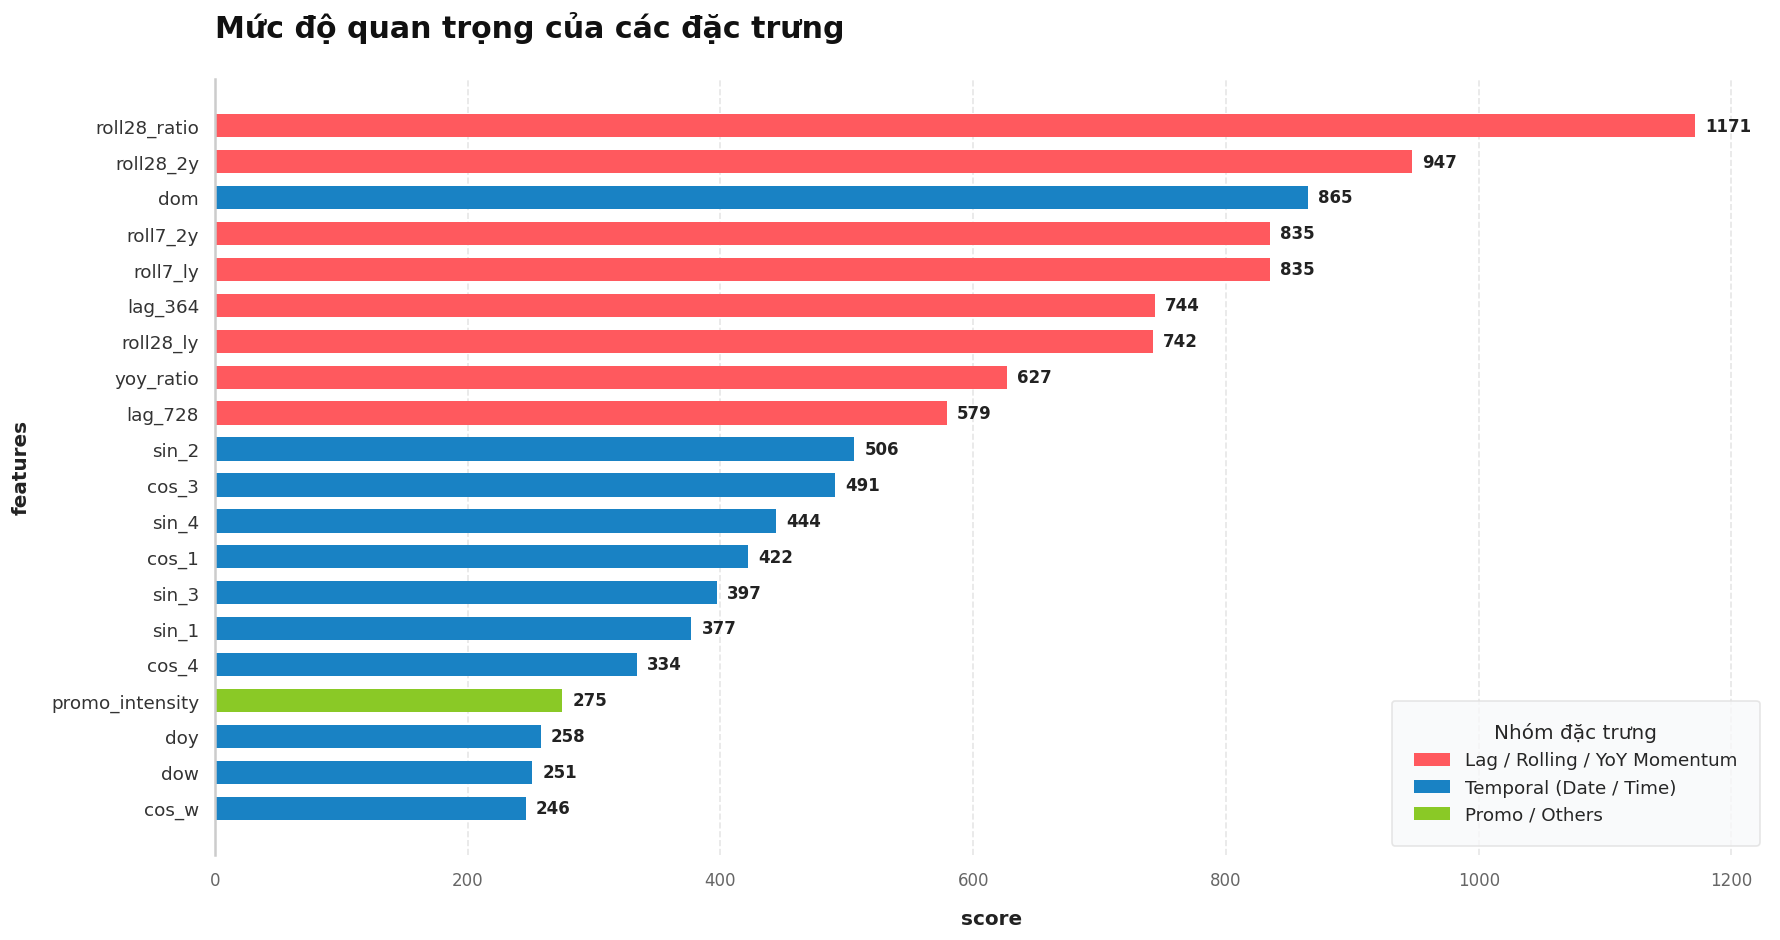

In [67]:
# Top 20 features
fi = (pd.DataFrame({'feature': FEAT_COLS, 'importance': m_full.feature_importances_})
      .sort_values('importance', ascending=False))
fi_top = fi.head(20).copy()
fi_top = fi_top.sort_values(by='importance', ascending=True)

def get_color(feat):
    if any(x in feat for x in ['lag', 'roll', 'yoy', 'cr_']):
        return COLOR_LAG
    elif any(x in feat for x in ['sin', 'cos', 'month', 'dom', 'dow', 'doy', 'quarter']):
        return COLOR_TEMP
    else:
        return COLOR_PROMO

colors = [get_color(f) for f in fi_top['feature']]

fig, ax = plt.subplots(figsize=(15, 8), dpi=120)
bars = ax.barh(fi_top['feature'], fi_top['importance'], color=colors, height=0.65, edgecolor='none')
ax.bar_label(bars, padding=6, fmt='%d', fontsize=10, color='#222222', fontweight='bold')

ax.set_xlabel('score', fontsize=12, fontweight='bold', color='#222222', labelpad=12)
ax.set_ylabel('features', fontsize=12, fontweight='bold', color='#222222', labelpad=12)
ax.tick_params(axis='y', labelsize=11, colors='#333333')
ax.tick_params(axis='x', labelsize=10, colors='#666666')
ax.xaxis.grid(True, linestyle='--', color='#E0E0E0', alpha=0.8)
ax.yaxis.grid(False)
for spine in ['top', 'right', 'bottom']:
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['left'].set_linewidth(1.5)
ax.set_title('Mức độ quan trọng của các đặc trưng', 
             fontsize=18, fontweight='heavy', color='#111111', pad=25, loc='left')
legend_elements = [
    Patch(facecolor=COLOR_LAG, edgecolor='none', label='Lag / Rolling / YoY Momentum'),
    Patch(facecolor=COLOR_TEMP, edgecolor='none', label='Temporal (Date / Time)'),
    Patch(facecolor=COLOR_PROMO, edgecolor='none', label='Promo / Others')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=11, frameon=True, 
          facecolor='#F8F9FA', edgecolor='#E0E0E0', borderpad=1.2, title='Nhóm đặc trưng', title_fontsize=12)
plt.tight_layout()
plt.show()

In [68]:
# ── Test prediction
print(f"Test predictions: mean={vp_final_test.mean():,.0f}  std={vp_final_test.std():,.0f}  max={vp_final_test.max():,.0f}")
print(f"Sample baseline : mean={df_sample_submission['Revenue'].mean():,.0f}  std={df_sample_submission['Revenue'].std():,.0f}  max={df_sample_submission['Revenue'].max():,.0f}")

Test predictions: mean=3,413,302  std=1,571,537  max=10,011,640
Sample baseline : mean=3,249,795  std=1,581,698  max=9,283,417


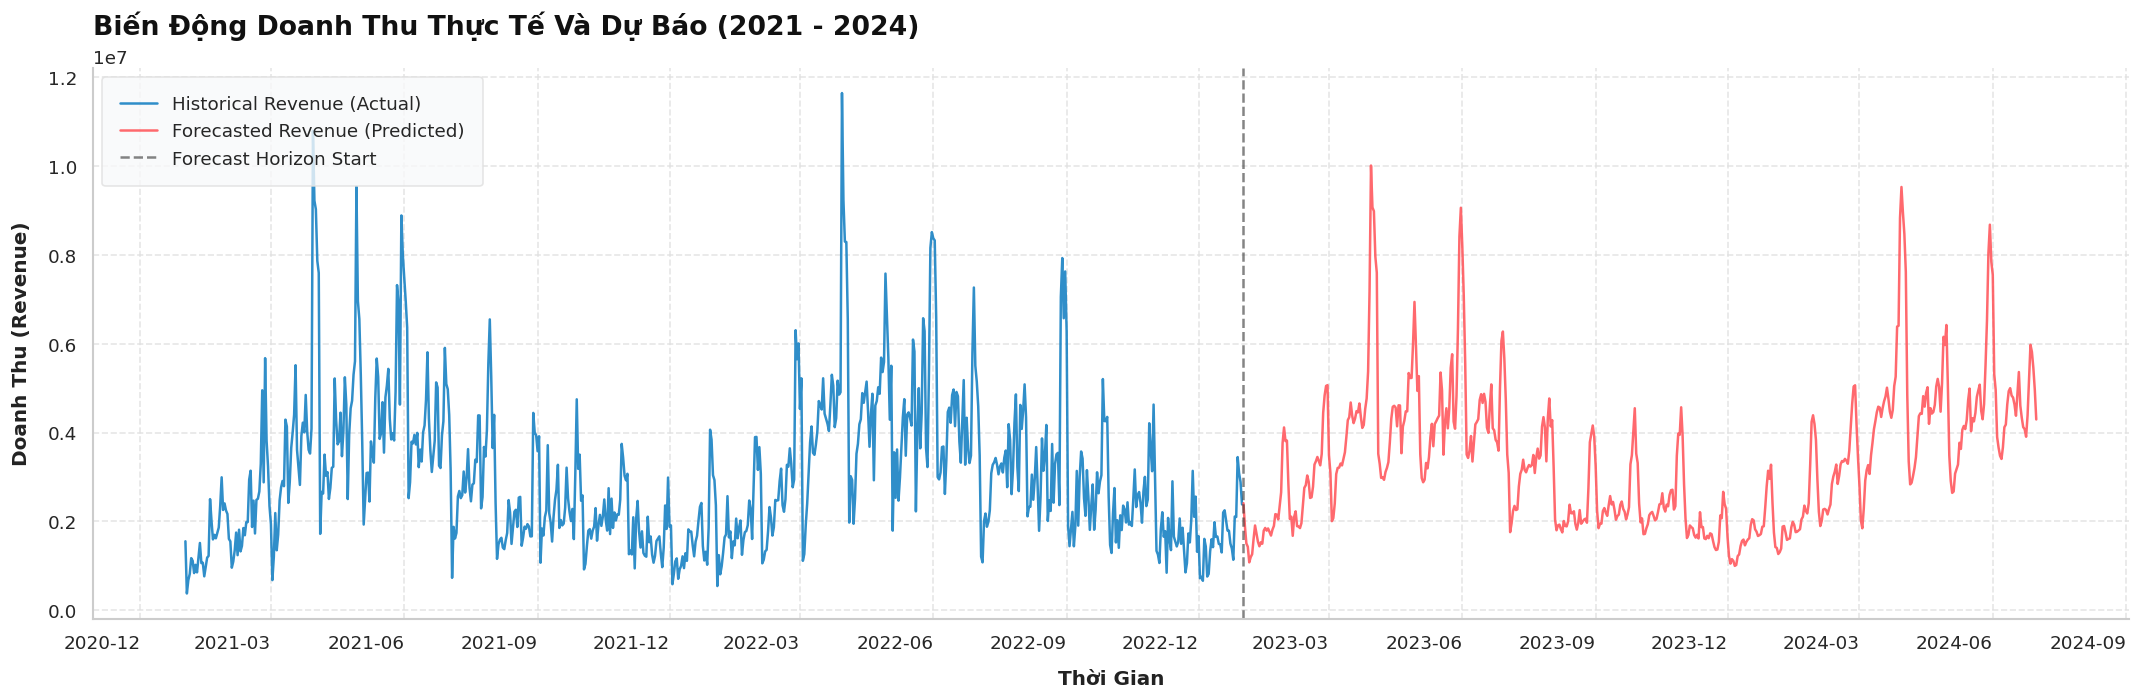

In [76]:
# Plot
plot_start_date = pd.Timestamp('2021-01-01')
history_mask = (df_pred['Date'] >= plot_start_date) & (df_pred['Date'] < TEST_START)
history_df = df_pred[history_mask]
fig, ax = plt.subplots(figsize=(18, 6), dpi=120)
fig.patch.set_facecolor('#FFFFFF')
ax.set_facecolor('#FFFFFF')

# Historical
ax.plot(history_df['Date'], history_df['Revenue'], 
        color='#1982C4', label='Historical Revenue (Actual)', linewidth=1.5, alpha=0.9)

# Forecasting
ax.plot(submission['Date'], submission['Revenue'], 
        color='#FF595E', label='Forecasted Revenue (Predicted)', linewidth=1.5, alpha=0.9)

ax.axvline(x=TEST_START, color='#333333', linestyle='--', linewidth=1.5, alpha=0.6, label='Forecast Horizon Start')
ax.set_title('Biến Động Doanh Thu Thực Tế Và Dự Báo (2021 - 2024)', 
             fontsize=16, fontweight='heavy', color='#111111', pad=20, loc='left')
ax.set_ylabel('Doanh Thu (Revenue)', fontsize=12, fontweight='bold', color='#222222', labelpad=10)
ax.set_xlabel('Thời Gian', fontsize=12, fontweight='bold', color='#222222', labelpad=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3)) 
fig.autofmt_xdate(rotation=0) 
ax.grid(True, linestyle='--', color='#E0E0E0', alpha=0.8)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('#CCCCCC')
ax.spines['left'].set_color('#CCCCCC')
ax.legend(loc='upper left', fontsize=11, frameon=True, facecolor='#F8F9FA', edgecolor='#E0E0E0', borderpad=1)
plt.tight_layout()
plt.show()

## 10. Model Explaination

In [69]:
import shap

shap.initjs()
explainer = shap.TreeExplainer(m_full)
X_explain = X_va.copy() 
shap_values = explainer(X_explain) 
shap_values_matrix = explainer.shap_values(X_explain)

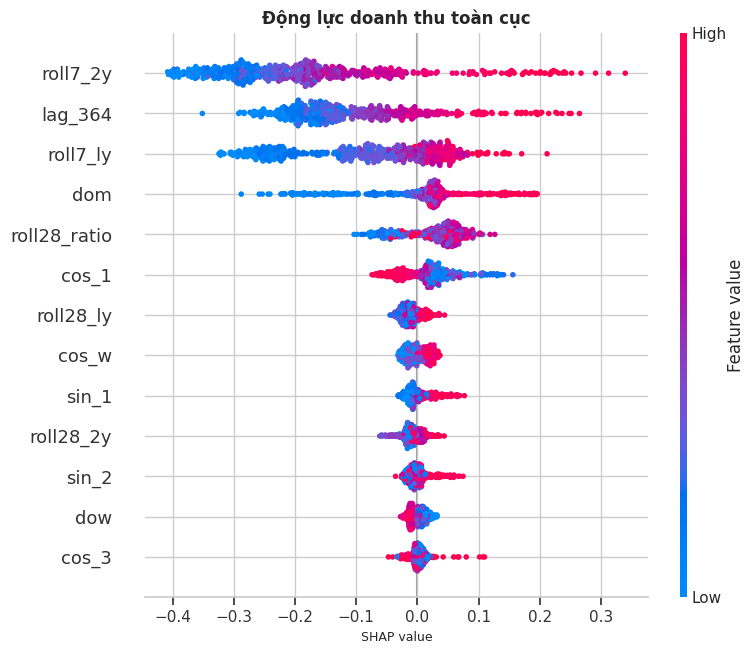

In [70]:
# ==============================================================================
# SHAP SUMMARY PLOT
# ==============================================================================
plt.figure(figsize=(15, 6))
shap.summary_plot(shap_values_matrix, X_explain, max_display=13, show=False)
plt.title("Động lực doanh thu toàn cục", fontsize=12, fontweight='bold')
plt.xlabel("SHAP value", fontsize=9)
plt.tight_layout()
plt.show()

**Nhận xét:** Biểu đồ chỉ ra rằng nhóm đặc trưng tự hồi quy (  `roll7_2y`, `lag_364`) đóng vai trò chi phối.

Điều này khẳng định doanh thu bán lẻ của doanh nghiệp có tính kế thừa và lặp lại cực kỳ mạnh mẽ theo chu kỳ năm. Nếu doanh nghiệp duy trì được đà tăng trưởng tốt trong một tuần so với cùng kỳ năm ngoái, đó là tín hiệu tin cậy nhất cho thấy doanh thu sắp tới sẽ khả quan. 


Giải thích chi tiết ngày đạt đỉnh doamh thu: 2022-03-30


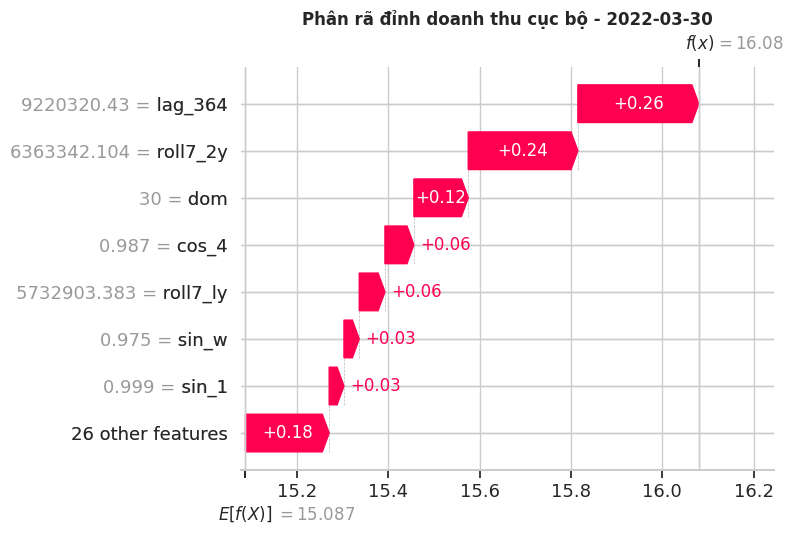

In [71]:
# ==============================================================================
# WATERFALL PLOT
# ==============================================================================
max_pred_idx = np.argmax(m_full.predict(X_explain))
max_date = df.loc[val_mask, 'Date'].iloc[max_pred_idx]

print(f"\nGiải thích chi tiết ngày đạt đỉnh doamh thu: {max_date.date()}")

fig, ax = plt.subplots(figsize=(15, 6))
shap.plots.waterfall(shap_values[max_pred_idx], max_display=8, show=False)
plt.title(f"Phân rã đỉnh doanh thu cục bộ - {max_date.date()}", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**Nhận xét:** Phân rã SHAP Waterfall vào ngày đạt đỉnh doanh thu (30/03/2022) cho thấy điểm kỳ dị này là sự cộng hưởng của ba yếu tố: 

- Cường độ khuyến mãi lịch sử cao.
- `lag_364` mang tín hiệu dương mạnh mẽ
- Hiệu ứng chốt sổ cuối quý (`is_qtr_end`). 

<Figure size 1200x600 with 0 Axes>

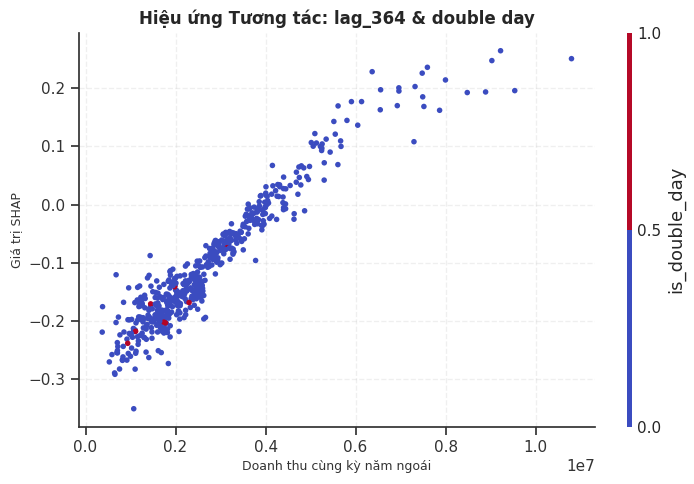

In [72]:
# ==============================================================================
# DEPENDENCE PLOT
# ==============================================================================
plt.figure(figsize=(10, 5), dpi=120)
shap.dependence_plot(
    "lag_364", 
    shap_values_matrix, 
    X_explain, 
    interaction_index="is_double_day",
    show=False,
    cmap=plt.get_cmap("coolwarm") # Đổi màu cho hiện đại hơn
)
plt.title("Hiệu ứng Tương tác: lag_364 & double day", fontsize=12, fontweight='bold')
plt.xlabel("Doanh thu cùng kỳ năm ngoái", fontsize=9)
plt.ylabel("Giá trị SHAP", fontsize=9)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

**Nhận xét:** Biểu đồ chứng minh giá trị biên của `lag_364` tăng phi tuyến tính và bùng nổ khi kết hợp với biến sự kiện `is_double_day`. 

Điều này khuyến nghị doanh nghiệp nên dồn lực phân bổ ngân sách marketing vào các "Ngày Đôi" ở những tháng mà dữ liệu năm ngoái đã ghi nhận mức cầu cao, qua đó tối đa hóa tỷ suất hoàn vốn (ROI).

## The end